In [7]:
import sys

import numpy as np
import pandas as pd
import scipy.stats as ss

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import pytorch_lightning as pl

In [8]:
sys.path.append('../model/')
import stability_data

from legnet import LegNetClassifier
from pl_regressor import RNARegressor

In [9]:
PATH_FROM = './ratios_log_stability.csv'
df_src = pd.read_csv(PATH_FROM)
df_src.head(3)

,seq,fold,log_ratio
0,AAAAAAAAACAACAGCACCTGTCCAGGCTTCCTTAGGTACATCTTC...,train,-0.806329
1,AAAAAACTCACCCGTTTTCCTGGGATTTGTTGTAAGGAGTTTTCAC...,train,-0.798038
2,AAAAAGACATAAACTGGCACCAGTTAACTTTCTTGTACTTTTTTGC...,train,-0.843010


In [10]:
df_src_filtered = df_src.copy()

In [11]:
Y_NAME = "log_ratio"

In [12]:
predict_set = stability_data.StabilityData(
    df=df_src_filtered,
    features=("sequence",),
    predict_cols=[Y_NAME],
)

dl_predict = DataLoader(
    predict_set,
    batch_size=1024,
    num_workers=16,
    shuffle=False,
    drop_last=False,
)

In [14]:
progressbar_callback = pl.callbacks.TQDMProgressBar(refresh_rate=0.5)
trainer = pl.Trainer(
    callbacks=[progressbar_callback],
    accelerator="gpu",
    devices=1,
    deterministic=True,
)
best_model = RNARegressor.load_from_checkpoint("./saved_models/stability-epoch=24-step=725.ckpt")

prediction = trainer.predict(model=best_model, dataloaders=dl_predict)
pred, real = zip(*prediction)
pred = torch.concat(pred).numpy()
real = torch.concat(real).numpy()
df_src_filtered["prediction"] = pred[:, 0]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Missing logger folder: /home/arsen_l/rna-legnet/wp6_clean_repo/parade-private/predictor/regression_stability/lightning_logs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Predicting: 0it [00:00, ?it/s]

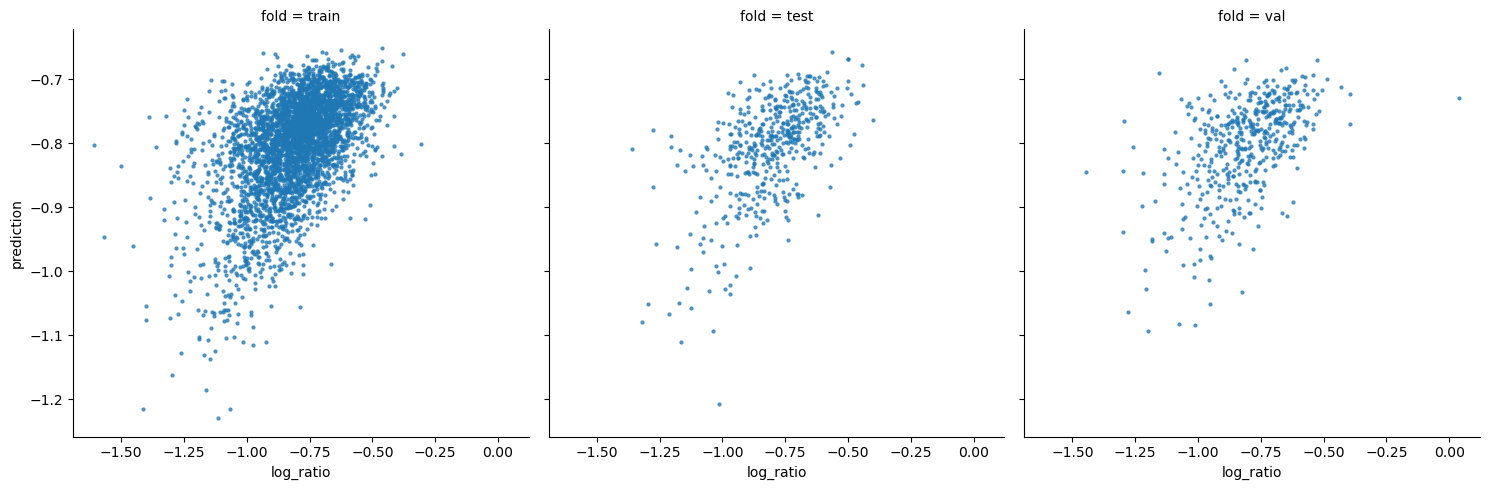

In [15]:
sns.relplot(df_src_filtered, x=Y_NAME, y="prediction", col="fold", marker=".", lw=0, alpha=0.8)

In [16]:
for group, group_df in df_src_filtered.groupby("fold"):
    varx = group_df[Y_NAME]
    vary = group_df["prediction"]
    r = ss.pearsonr(varx, vary).statistic
    print(f"{group} {r:.05f}")

test 0.58169
train 0.52181
val 0.52728


In [18]:
df_src_filtered.to_csv("ratios_log_stability_predictions.csv", index=False)

---